        family_id         sequence_name family_accession  \
0    zf-Tim10_DDP    N1QB11_PSEFD/15-76       PF02953.15   
1   DNA_primase_S  A8XA78_CAEBR/105-345       PF01896.19   
2   Col_cuticle_N     A8XBM5_CAEBR/9-56       PF01484.17   
3         GST_C_3  W4XBU3_STRPU/120-207        PF14497.6   
4  Ada_Zn_binding     E8U5K2_DEIML/9-73       PF02805.16   

                                    aligned_sequence  \
0  ..RMEKKQMKDFMNMYSNLVQRCFNDCV...........TD.F......   
1  FDID..LTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFG...   
2  ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIA...   
3  KD.................................KLKESLPKTVN...   
4  DRWQAVVQRE...AAQ.DG...LFLYAVRTTGIYCRPSCPSRRPR....   

                                            sequence  
0  RMEKKQMKDFMNMYSNLVQRCFNDCVTDFTSKSLQSKEEGCVMRCV...  
1  FDIDLTDYDNIRNCCKEATVCPKCWKFMVLAVKILDFLLDDMFGFN...  
2   ASAAILSGATIVGCLFFAAQIFNEVNSLYDDVMVDMDAFKVKSNIAWD  
3  KDKLKESLPKTVNPILLKFLEKALEDNPNGNGYFVGQDATMVEFVY...  
4  DRWQAVVQREAAQDGLFLYAVRTT

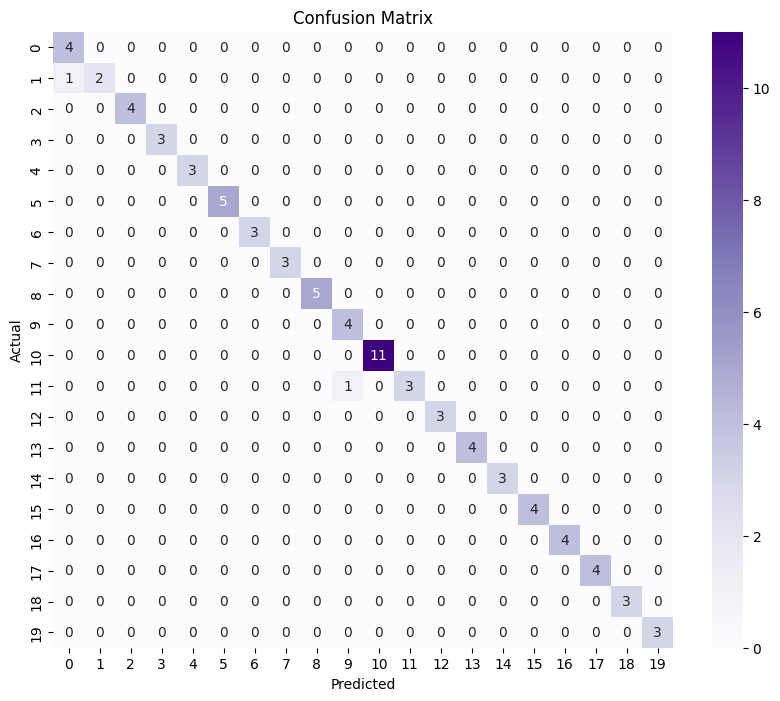

Methyltransf_25


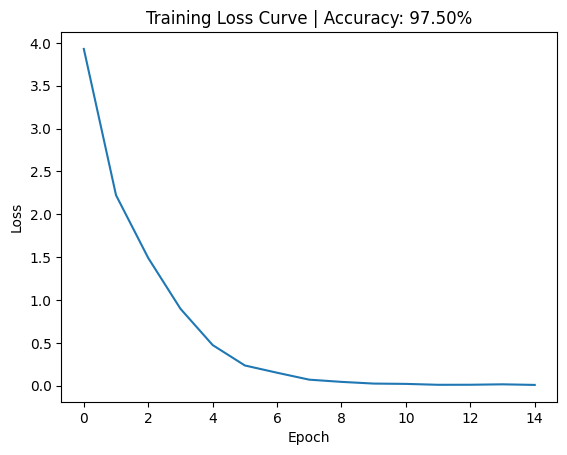

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

df = pd.read_csv('protein_data')

print(df.head())

df = df[['family_id', 'sequence']]

df.dropna(inplace=True)

top_families = df['family_id'].value_counts().head(20).index

df = df[df['family_id'].isin(top_families)]

print(df['family_id'].value_counts())

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'

aa_to_int = {}

for i, aa in enumerate(amino_acids):
    aa_to_int[aa] = i + 1

def encode_sequence(sequence):

    encoded = []

    for aa in sequence:
        encoded.append(aa_to_int.get(aa, 0))

    return encoded

df['encoded_sequence'] = df['sequence'].apply(encode_sequence)

max_length = 300

def sequence_padding(sequence, max_length):

    if len(sequence) > max_length:
        sequence = sequence[:max_length]

    padded = sequence + [0] * (max_length - len(sequence))

    return padded

df['padded_sequence'] = df['encoded_sequence'].apply(
    lambda x: sequence_padding(x, max_length)
)

le = LabelEncoder()

df['class_encoded'] = le.fit_transform(df['family_id'])

X = np.array(df['padded_sequence'].tolist())

y = np.array(df['class_encoded'])

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)

test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class ProteinCNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_classes):

        super(ProteinCNN, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.conv1 = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=128,
            kernel_size=5
        )

        self.pool = nn.MaxPool1d(kernel_size=2)

        conv_output_size = ((max_length - 5 + 1) // 2)

        self.fc1 = nn.Linear(
            128 * conv_output_size,
            128
        )

        self.fc2 = nn.Linear(
            128,
            num_classes
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = self.embedding(x)

        x = x.permute(0, 2, 1)

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = x.flatten(start_dim=1)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

vocab_size = len(aa_to_int) + 1

embedding_dim = 64

num_classes = len(df['class_encoded'].unique())

model = ProteinCNN(
    vocab_size,
    embedding_dim,
    num_classes
)

print(model)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 15

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.numpy())

        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f'Accuracy: {accuracy * 100:.2f}%')
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions
))
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()
def predict_protein_family(sequence):

    encoded = []

    for aa in sequence:
        encoded.append(aa_to_int.get(aa, 0))

    if len(encoded) > max_length:
        encoded = encoded[:max_length]

    padded = encoded + [0] * (max_length - len(encoded))

    input_tensor = torch.tensor(
        [padded],
        dtype=torch.long
    )

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        _, predicted = torch.max(output, 1)

    family = le.inverse_transform(
        [predicted.item()]
    )

    return family[0]
#Test Prediction
sample_sequence = df.iloc[0]['sequence']

prediction = predict_protein_family(sample_sequence)

print(prediction)

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(f"Training Loss Curve | Accuracy: {accuracy*100:.2f}%")

plt.show()
torch.save(
    model.state_dict(),
    'pfam_cnn_model.pth'
)